# GliZNet — Full Benchmark Evaluation

Evaluates **GliZNet** (DeBERTa-v3-base backbone) on the same 10 datasets used in the GLiClass benchmark paper, reporting **macro F1** for direct comparison.

**Datasets**: CR, SST-2, SST-5, IMDb, 20-Newsgroups, Enron Spam, Financial PhraseBank, AG News, Emotion, Rotten Tomatoes

| Model | Avg macro F1 |
|---|---|
| GLiClass-large-v3.0 | 0.7417 |
| GLiClass-base-v3.0 | 0.7056 |
| GLiClass-modern-base-v3.0 | 0.6170 |
| **GliZNet — VICReg + custom data only (ours)** | **0.6473** |
| GliZNet — bilinear, full data (ours) | 0.6301 |
| GliZNet — cosine, full data (ours) | 0.6214 |


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, ClassLabel
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

from gliznet import ZeroShotClassificationPipeline
from gliznet.tokenizer import GliZNETTokenizer
from gliznet.model import GliZNetForSequenceClassification

DEVICE     = "cuda:0" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "../results/deberta-v3-base_20260430_111022/checkpoint-1122"
BATCH_SIZE = 32

print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_PATH}")

Device : cuda:0
Model  : ../results/deberta-v3-base_20260430_111022/checkpoint-1122


In [2]:
# Load GliZNet pipeline
pipeline = ZeroShotClassificationPipeline.from_pretrained(
    MODEL_PATH,
    classification_type="multi-class",
    device=DEVICE,
)
print("✓ GliZNet loaded")

# Sanity check
out = pipeline("I absolutely loved this film!", ["positive", "negative", "neutral"])
for ls in out.labels:
    print(f"  {ls.label:<12} {ls.score:.3f}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

✓ GliZNet loaded
  positive     1.000
  negative     0.000
  neutral      0.000


## Dataset loading helpers

In [3]:
def get_test_split(ds):
    """Return the test (or fallback validation/train) split."""
    for key in ("test", "validation", "train"):
        if key in ds:
            return ds[key]
    raise ValueError("No usable split found")


def resolve_labels(split, label_col):
    """Return (class_names: list[str], int_to_str callable).
    Handles ClassLabel features and plain int/string columns.
    Classes are always returned as strings so the tokenizer never receives ints.
    """
    feat = split.features.get(label_col)
    if isinstance(feat, ClassLabel):
        classes = feat.names          # already list[str]
        to_str = lambda i: classes[i]
    else:
        raw_classes = sorted(set(split[label_col]))
        classes = [str(c) for c in raw_classes]
        to_str = lambda x: str(x)
    return classes, to_str


def prepare(ds, text_col="text", label_col="label", classes=None, to_str=None):
    """Return (texts: list[str], classes: list[str], true_labels: list[str])."""
    split = get_test_split(ds)
    if classes is None:
        classes, to_str = resolve_labels(split, label_col)
    raw = split[label_col]
    true_labels = [to_str(l) for l in raw]
    return list(split[text_col]), classes, true_labels

In [4]:
def predict_batch(texts, classes, batch_size=BATCH_SIZE):
    """Return the top predicted class string for each text."""
    preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="  inference", leave=False):
        batch_texts = texts[i : i + batch_size]
        outputs = pipeline(batch_texts, classes)
        for out in outputs:
            best = max(out.labels, key=lambda ls: ls.score)
            preds.append(best.label)
    return preds


def evaluate(preds, true_labels):
    return {
        "macro":    f1_score(true_labels, preds, average="macro"),
        "micro":    f1_score(true_labels, preds, average="micro"),
        "weighted": f1_score(true_labels, preds, average="weighted"),
    }

## Run evaluation on all benchmarks

## Dataset inspection — load each one and check columns / label format

In [5]:
def inspect(ds_id, config=None, text_col=None, label_col=None):
    """Load a dataset and print its splits, columns, feature types and a few label samples."""
    print(f"\n{'─'*60}")
    print(f"  {ds_id}  {'(' + config + ')' if config else ''}")
    print(f"{'─'*60}")
    ds = load_dataset(ds_id, config) if config else load_dataset(ds_id)
    print(f"  Splits   : {list(ds.keys())}")
    split = get_test_split(ds)
    print(f"  Split    : {len(split)} rows")
    print(f"  Columns  : {split.column_names}")
    print(f"  Features : {split.features}")
    if text_col:
        print(f"  Text[0]  : {str(split[text_col][0])[:120]}")
    if label_col:
        sample_labels = split[label_col][:5]
        print(f"  Labels[0:5]: {sample_labels}")
        feat = split.features.get(label_col)
        if isinstance(feat, ClassLabel):
            print(f"  Class names: {feat.names[:10]}{'...' if len(feat.names)>10 else ''}")
        else:
            unique = sorted(set(split[label_col]))
            print(f"  Unique labels ({len(unique)}): {unique[:10]}{'...' if len(unique)>10 else ''}")

In [6]:
DATASETS = [
    "SetFit/CR",
    "SetFit/sst2",
    "SetFit/sst5",
    "stanfordnlp/imdb",
    "SetFit/20_newsgroups",
    "SetFit/enron_spam",
    "mteb/financial_phrasebank",
    "ag_news",
    "dair-ai/emotion",
    "cornell-movie-review-data/rotten_tomatoes",
]

results_all = {}

for dataset_id in DATASETS:
    print(f"\n{'='*60}")
    print(f"  {dataset_id}")
    print(f"{'='*60}")
    try:
        # ── per-dataset loading ──────────────────────────────────────
        if dataset_id == "stanfordnlp/imdb":
            classes = ["negative", "positive"]
            _to = (lambda c: lambda i: c[i])(classes)
            ds = load_dataset(dataset_id)
            texts, _, true_labels = prepare(ds, label_col="label", classes=classes, to_str=_to)

        elif dataset_id == "SetFit/enron_spam":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")

        elif dataset_id == "SetFit/20_newsgroups":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")
            remap = {c: c.replace(".", " ") for c in classes}
            classes = [remap[c] for c in classes]
            true_labels = [remap[l] for l in true_labels]

        elif dataset_id in ("SetFit/CR", "SetFit/sst2", "SetFit/sst5"):
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")

        elif dataset_id == "mteb/amazon_massive_intent":
            ds = load_dataset(dataset_id, "en")
            texts, classes, true_labels = prepare(ds, text_col="text", label_col="label")

        elif dataset_id == "mteb/banking77":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, text_col="text", label_col="label_text")

        elif dataset_id == "mteb/financial_phrasebank":
            classes = ["negative", "neutral", "positive"]
            _to = (lambda c: lambda i: c[i])(classes)
            ds = load_dataset(dataset_id, "sentences_allagree")
            texts, _, true_labels = prepare(ds, text_col="text", label_col="label", classes=classes, to_str=_to)

        else:
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds)

        print(f"  Samples : {len(texts)}")
        print(f"  Classes : {len(classes)}  → {classes[:6]}{'...' if len(classes) > 6 else ''}")

        preds  = predict_batch(texts, classes)
        scores = evaluate(preds, true_labels)
        results_all[dataset_id] = scores
        print(f"  macro F1 = {scores['macro']:.4f}  |  micro = {scores['micro']:.4f}")

    except Exception as exc:
        import traceback; traceback.print_exc()
        results_all[dataset_id] = {"macro": float("nan"), "micro": float("nan"), "weighted": float("nan")}

print("\n\n✓ All datasets done")



  SetFit/CR


Repo card metadata block was not found. Setting CardData to empty.


  Samples : 376
  Classes : 2  → ['negative', 'positive']


  inference:   0%|          | 0/12 [00:00<?, ?it/s]

  macro F1 = 0.8752  |  micro = 0.8883

  SetFit/sst2


...

  macro F1 = 0.7332  |  micro = 0.7424

  dair-ai/emotion
  Samples : 2000
  Classes : 6  → ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


  inference:   0%|          | 0/63 [00:00<?, ?it/s]

  macro F1 = 0.3991  |  micro = 0.4035

  cornell-movie-review-data/rotten_tomatoes
  Samples : 1066
  Classes : 2  → ['neg', 'pos']


  inference:   0%|          | 0/34 [00:00<?, ?it/s]

  macro F1 = 0.8009  |  micro = 0.8021


✓ All datasets done


## Results vs GLiClass benchmark

In [7]:
GLICLASS_BASE = {
    "SetFit/CR":                                    0.9127,
    "SetFit/sst2":                                  0.8959,
    "SetFit/sst5":                                  0.3236,
    "stanfordnlp/imdb":                             0.9248,
    "SetFit/20_newsgroups":                         0.5045,
    "SetFit/enron_spam":                            0.6252,
    "mteb/financial_phrasebank":                    0.9094,
    "ag_news":                                      0.7209,
    "dair-ai/emotion":                              0.4450,
    "cornell-movie-review-data/rotten_tomatoes":    0.7943,
}

GLICLASS_LARGE = {
    "SetFit/CR":                                    0.9281,
    "SetFit/sst2":                                  0.9176,
    "SetFit/sst5":                                  0.3798,
    "stanfordnlp/imdb":                             0.9366,
    "SetFit/20_newsgroups":                         0.5806,
    "SetFit/enron_spam":                            0.7574,
    "mteb/financial_phrasebank":                    0.9023,
    "ag_news":                                      0.7229,
    "dair-ai/emotion":                              0.4504,
    "cornell-movie-review-data/rotten_tomatoes":    0.8411,
}


GLICLASS_MODERN_BASE = {
    "SetFit/CR":                                    0.8936,
    "SetFit/sst2":                                  0.8982,
    "SetFit/sst5":                                  0.2885,
    "stanfordnlp/imdb":                             0.9154,
    "SetFit/20_newsgroups":                         0.3342,
    "SetFit/enron_spam":                            0.5903,
    "mteb/financial_phrasebank":                    0.4121,
    "ag_news":                                      0.7069,
    "dair-ai/emotion":                              0.4249,
    "cornell-movie-review-data/rotten_tomatoes":    0.7060,
}


rows = []
for ds_id in DATASETS:
    r = results_all.get(ds_id, {})
    rows.append({
        "dataset":                ds_id.split("/")[-1],
        "GliZNet (ours)":         round(r.get("macro", float("nan")), 4),
        "GLiClass-large-v3":      GLICLASS_LARGE.get(ds_id, float("nan")),
        "GLiClass-base-v3":       GLICLASS_BASE.get(ds_id, float("nan")),
        "GLiClass-modern-base":   GLICLASS_MODERN_BASE.get(ds_id, float("nan")),
    })

df = pd.DataFrame(rows).set_index("dataset")

avg = df.mean(numeric_only=True)
avg.name = "AVERAGE"
df = pd.concat([df, avg.to_frame().T])
df["Δ vs large"] = (df["GliZNet (ours)"] - df["GLiClass-large-v3"]).round(4)
df["Δ vs base"]  = (df["GliZNet (ours)"] - df["GLiClass-base-v3"]).round(4)

pd.set_option("display.float_format", "{:.4f}".format)
df


,GliZNet (ours),GLiClass-large-v3,GLiClass-base-v3,GLiClass-modern-base,Δ vs large,Δ vs base
CR,0.8752,0.9281,0.9127,0.8936,-0.0529,-0.0375
sst2,0.8839,0.9176,0.8959,0.8982,-0.0337,-0.0120
sst5,0.3969,0.3798,0.3236,0.2885,0.0171,0.0733
imdb,0.8855,0.9366,0.9248,0.9154,-0.0511,-0.0393
20_newsgroups,0.3877,0.5806,0.5045,0.3342,-0.1929,-0.1168
enron_spam,0.5164,0.7574,0.6252,0.5903,-0.2410,-0.1088
financial_phrasebank,0.5945,0.9023,0.9094,0.4121,-0.3078,-0.3149
ag_news,0.7332,0.7229,0.7209,0.7069,0.0103,0.0123
emotion,0.3991,0.4504,0.4450,0.4249,-0.0513,-0.0459
rotten_tomatoes,0.8009,0.8411,0.7943,0.7060,-0.0402,0.0066


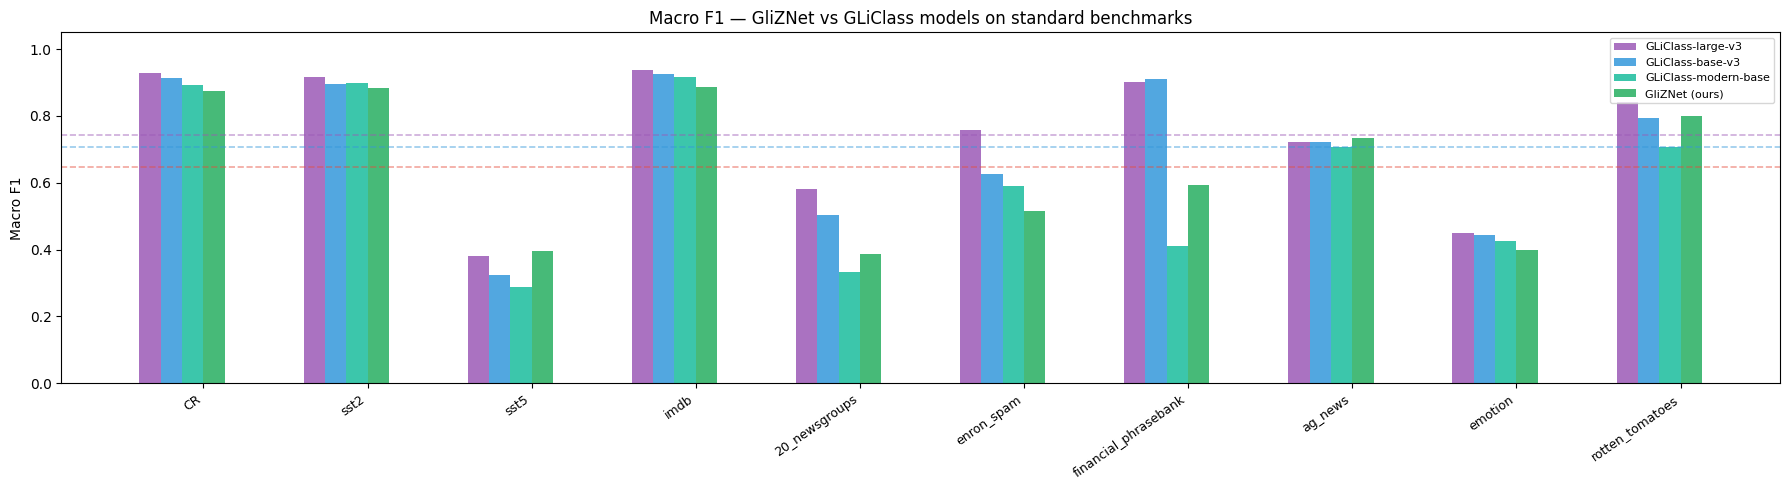


GliZNet avg macro F1        : 0.6473
GLiClass-large avg          : 0.7417  (Δ -0.0943)
GLiClass-base avg           : 0.7056  (Δ -0.0583)
GLiClass-modern-base avg    : 0.6170  (Δ +0.0303)


In [8]:
plot_df = df.drop("AVERAGE").dropna()
x = np.arange(len(plot_df))
w = 0.13

fig, ax = plt.subplots(figsize=(18, 5))
offsets = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
colors  = ["#9b59b6", "#3498db", "#1abc9c", "#27ae60", "#f39c12", "#e74c3c"]
cols    = ["GLiClass-large-v3", "GLiClass-base-v3", "GLiClass-modern-base", "GliZNet (ours)"]
labels  = ["GLiClass-large-v3", "GLiClass-base-v3",
           "GLiClass-modern-base", "GliZNet (ours)"]

for off, col, lbl, clr in zip(offsets, cols, labels, colors):
    ax.bar(x + off * w, plot_df[col], w, label=lbl, color=clr, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.05)
ax.set_title("Macro F1 — GliZNet vs GLiClass models on standard benchmarks")
ax.legend(loc="upper right", fontsize=8)

gliznet_avg        = df.loc["AVERAGE", "GliZNet (ours)"]
glibase_avg        = df.loc["AVERAGE", "GLiClass-base-v3"]
glilarge_avg       = df.loc["AVERAGE", "GLiClass-large-v3"]
glimod_base_avg    = df.loc["AVERAGE", "GLiClass-modern-base"]

ax.axhline(gliznet_avg,  color="#e74c3c", ls="--", lw=1.2, alpha=0.5)
ax.axhline(glibase_avg,  color="#3498db", ls="--", lw=1.2, alpha=0.5)
ax.axhline(glilarge_avg, color="#9b59b6", ls="--", lw=1.2, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nGliZNet avg macro F1        : {gliznet_avg:.4f}")
print(f"GLiClass-large avg          : {glilarge_avg:.4f}  (Δ {gliznet_avg - glilarge_avg:+.4f})")
print(f"GLiClass-base avg           : {glibase_avg:.4f}  (Δ {gliznet_avg - glibase_avg:+.4f})")
print(f"GLiClass-modern-base avg    : {glimod_base_avg:.4f}  (Δ {gliznet_avg - glimod_base_avg:+.4f})")
